# Chapter 15: Query Performance

**Level 4: Expert** · ⏱ about 3 hours · Dataset: *EduGraph at scale* (≈ 610,000 triples, generated)

### What you will learn

1. **Where the time goes**: network, planning, execution, result transfer
2. Reading **query plans**: operators, indexes and **cardinality estimates**, which warn you before you run a query
3. **Profiling**: measured time and memory per operator
4. Six **anti-patterns** and their rewrites, each measured
5. **Benchmarking** from Python: warm-ups, repeats and medians
6. **Safety nets**: query timeouts and killing runaway queries

The chapter generates a larger EduGraph (15,000 students, about 126,000 assessments) and loads it into a temporary named graph. It briefly lowers the database's `query.timeout` in 15.6, and restores it.

In [1]:
import sys
import tempfile
import time
from pathlib import Path

TUTORIAL = Path('..').resolve()
for p in (str(TUTORIAL / 'src'), str(TUTORIAL / 'data' / 'generators')):
    if p not in sys.path:
        sys.path.insert(0, p)

import matplotlib.pyplot as plt
import pandas as pd
import stardog

from edugraph_scale import generate
from kg import client, dboptions, perf, sparql

pd.set_option('display.max_colwidth', 100)
conn = client.connect()
SIS, CURRICULUM = 'urn:tutorial:ch15:sis', 'urn:tutorial:ch15:curriculum'
GRAPHS = [SIS, CURRICULUM]

start = time.perf_counter()
data_file, triples = generate(Path(tempfile.mkdtemp()) / 'edugraph_scale.nt.gz', students=15_000)
print(f'generated {triples:,} triples ({data_file.stat().st_size / 1e6:.1f} MB compressed) in {time.perf_counter() - start:.1f}s')

start = time.perf_counter()
with client.transaction(conn) as stats:
    for g in GRAPHS:
        conn.clear(graph_uri=g)
    conn.add(stardog.content.File(str(data_file)), graph_uri=SIS)
    conn.add(stardog.content.File(str(TUTORIAL / 'data' / 'edugraph' / 'curriculum.ttl')), graph_uri=CURRICULUM)
print(f"loaded {stats['added']:,} triples in {time.perf_counter() - start:.1f}s")

P = 'PREFIX edu: <http://example.org/edu#>\nPREFIX student: <http://example.org/edu/student/>\n'

generated 609,399 triples (2.9 MB compressed) in 6.2s


loaded 609,540 triples in 22.5s


Same IRIs and properties as the Chapter 10 mappings, so every EduGraph query works unchanged, just on 400 times more students.

`kg.perf` has three helpers:

| Function | Does |
|---|---|
| `bench(conn, query, graphs, runs=3)` | Warm-up run, then `runs` timed runs → median, min, row count |
| `compare(conn, {name: query}, graphs)` | `bench` for several queries, as a table |
| `plan(conn, query, graphs, profile=False)` | The query plan; with `profile=True` the query is **run** and each operator reports its time and memory |

## 15.1 Where the time goes

A query's time is the sum of: **network** round trip → **parsing and planning** → **execution** → **serializing** the results → **transferring** them back. On Stardog Cloud from a laptop, the round trip alone is a good part of every query:

In [2]:
perf.compare(conn, {
    'trivial: one row':                  'SELECT ?x { BIND(1 AS ?x) }',
    'count 126k assessments':            P + 'SELECT (COUNT(*) AS ?n) { ?a edu:score ?s }',
    'average per topic (126k → 21 rows)': P + 'SELECT ?t (AVG(?s) AS ?avg) { ?a edu:topic ?t ; edu:score ?s } GROUP BY ?t',
}, GRAPHS)

,median_s,min_s,rows
trivial: one row,0.260,0.257,1.0
count 126k assessments,0.302,0.301,1.0
average per topic (126k → 21 rows),0.333,0.332,21.0


A trivial query and one that aggregates 126,000 assessments take almost the same time: most of it is the **round trip**, and the server itself is fast. Two consequences:

- Don't optimize a query that is already dominated by network time. Look at **what the server does** (the plan and profile), not only at the stopwatch.
- **Fewer, larger requests** beat many small ones (Chapter 5's batch loading showed the same thing).

## 15.2 Reading query plans

`plan()` shows how Stardog will execute a query, without running it:

In [3]:
AVG_PER_TOPIC = P + '''SELECT ?name (AVG(?score) AS ?avg)
WHERE { ?a edu:topic ?t ; edu:score ?score . ?t edu:name ?name }
GROUP BY ?name'''
print(perf.plan(conn, AVG_PER_TOPIC, GRAPHS))

From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?name, ?avg) [#125K]
`─ Group(by=[?name] aggregates=[(AVG(?score) AS ?avg)]) [#125K]
   `─ Restriction(?score, ?name) [#125K]
      `─ HashJoin(?t) [#125K]
         +─ MergeJoin(?a) [#125K]
         │  +─ Scan[PSOC](?a, edu:topic, ?t) [#126K]
         │  `─ Scan[PSOC](?a, edu:score, ?score) [#126K]
         `─ Scan[PSOC](?t, edu:name, ?name) [#15K]


Read it **bottom-up**: the leaves produce rows, and each parent consumes its children's rows.

| Element | Meaning |
|---|---|
| `Scan[PSOC](?a, edu:topic, ?t)` | Read triples from an **index**. `PSOC` = sorted by predicate, subject, object, context (graph). Stardog keeps several orders (`SPOC`, `POSC`, `PSOC`, …) and picks the one where the known parts come first |
| `MergeJoin(?a)` | Join two inputs already **sorted** on `?a`: very cheap |
| `HashJoin(?t)` | Build a hash table from one side, probe with the other: good when inputs aren't sorted the same way; costs memory |
| `NestedLoopJoin` | Combine **every** row with every row: a warning sign (15.4) |
| `Filter(…)`, `Group(…)`, `Sort`, `Slice` | `FILTER`, `GROUP BY`, `ORDER BY`, `LIMIT/OFFSET` |
| `[#126K]` | The optimizer's **estimate** of how many rows this step produces |

The estimates come from **statistics** Stardog keeps about the data. They're what the optimizer uses to choose join orders and algorithms. And they let **you** spot a disaster before running it.

## 15.3 Profiling

`profile=True` **runs** the query and annotates every operator with its actual rows, wall time and memory:

In [4]:
print(perf.plan(conn, AVG_PER_TOPIC, GRAPHS, profile=True))

Profiling results:
Query executed in 135 ms and returned 21 result(s)
Total used memory: 1.8M
Pre-execution time: 2 ms (1.5%)
Post-processing time: 0 ms (0.0%)
Query plan execution: 133 ms (98.5%)
From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?name, ?avg) [#125K], results: 21, wall time: 0 ms (0.0%)
`─ Group(by=[?name] aggregates=[(AVG(?score) AS ?avg)]) [#125K], memory: {total=384K (21.4%); max=352K}, results: 21, wall time: 27 ms (20.3%)
   `─ Restriction(?score, ?name) [#125K], results: 126K (next: 268, avg batch: 470), wall time: 0 ms (0.0%)
      `─ HashJoin(?t) [#125K], memory: {total=1.4M (78.6%); max=1.1M}, results: 126K (next: 268, avg batch: 470), wall time: 53 ms (39.8%)
         +─ MergeJoin(?a) [#125K], results: 126K (next: 268, avg batch: 470), wall time: 6 ms (4.5%)
         │  +─ Scan[PSOC](?a, http://example.org/edu#topic, ?t) [#126K], results: 126K (next: 999, avg batch: 126), wall time: 21 ms (15.8%)
         │  `─ Scan[PSOC](?a, http://

Now you see where the time really goes, e.g. how much of the total is the join versus the grouping, and whether the **estimates** (`[#…]`) matched the **actual** results. Large mismatches mean the optimizer planned on wrong numbers, and are the first thing to investigate when a plan looks odd.

## 15.4 Anti-patterns and their rewrites

Each pattern below is **measured** on the 610,000-triple graph.

### 1. Moving data instead of questions

Computing in pandas what the database could compute ships every row across the network:

In [5]:
q_fetch = P + 'SELECT ?s ?score { ?a edu:student ?s ; edu:score ?score }'
q_server = P + 'SELECT ?city (AVG(?score) AS ?avg) { ?a edu:student ?s ; edu:score ?score . ?s edu:city ?city } GROUP BY ?city'

start = time.perf_counter()
rows = sparql.run_query(conn, q_fetch, graphs=GRAPHS)
cities = sparql.run_query(conn, P + 'SELECT ?s ?city { ?s edu:city ?city }', graphs=GRAPHS)
by_city_pandas = rows.merge(cities, on='s').groupby('city').score.mean()
pandas_seconds = time.perf_counter() - start

server = perf.bench(conn, q_server, GRAPHS)
pd.DataFrame({'fetch 126k + 15k rows, aggregate in pandas': {'seconds': round(pandas_seconds, 2), 'rows transferred': len(rows) + len(cities)},
              'aggregate on the server':                     {'seconds': server['median_s'], 'rows transferred': server['rows']}}).T

,seconds,rows transferred
"fetch 126k + 15k rows, aggregate in pandas",3.850,141087.0
aggregate on the server,0.385,10.0


Same answer, a fraction of the time. **Aggregate, filter and join on the server**; transfer only the result.

### 2. Functions around variables hide the index

In [6]:
for label, q in [('FILTER(STR(?c) = "Berlin")', 'SELECT ?s { ?s edu:city ?c FILTER(STR(?c) = "Berlin") }'),
                 ('literal in the pattern',     'SELECT ?s { ?s edu:city "Berlin" }')]:
    print(f'--- {label}')
    print(perf.plan(conn, P + q, GRAPHS))

--- FILTER(STR(?c) = "Berlin")


From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?s) [#37]
`─ Filter("Berlin" = Str(?c)) [#37]
   `─ Scan[POSC](?s, edu:city, ?c) [#15K]
--- literal in the pattern


From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?s) [#1.5K]
`─ Scan[POSC](?s, edu:city, "Berlin") [#1.5K]


- With the literal **in the pattern**, the index jumps straight to the matching triples: `Scan[POSC](?s, edu:city, "Berlin")`, about 1.5K rows.
- Wrapped in `STR(…)` inside a `FILTER`, Stardog must read **all** 15K cities and test each one. The estimate `[#37]` is also far off, so any join above it would be planned badly.

On 15,000 cities both run in a blink. On 15 million, only one of them does. **Put constants into triple patterns; keep functions out of join and filter keys.** `CONTAINS`/`REGEX` always scan (use full-text search, Chapter 12, for text).

### 3. Disconnected patterns: the cartesian product

Two patterns that share **no variable** produce every combination of their rows:

In [7]:
CARTESIAN = P + 'SELECT (COUNT(*) AS ?n) { ?a edu:score ?x . ?b edu:city ?y }'
print(perf.plan(conn, CARTESIAN, GRAPHS))

From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?n) [#1]
`─ Group(aggregates=[(COUNT(*) AS ?n)]) [#1]
   `─ NestedLoopJoin(_) [#1879.3M]
      +─ Scan[PSOC](?b, edu:city, ?y) [#15K]
      `─ Scan[PSOC](?a, edu:score, ?x) [#126K]


`NestedLoopJoin(_) [#1878.4M]`: the plan predicts **1.9 billion** combinations before the query runs. It's almost always a **mistake**: a typo in a variable name, or a forgotten join pattern. **Read the plan of any query that is unexpectedly slow, and look for `NestedLoopJoin` and huge estimates.** Section 15.6 runs this query safely.

### 4. Unanchored joins

"Students who share a course" joins the enrollments with themselves. **Anchored** on one student, it's small. For **everyone**, it's enormous:

In [8]:
print('--- anchored on one student')
print(perf.plan(conn, P + 'SELECT (COUNT(DISTINCT ?o) AS ?n) { student:X00042 edu:enrolledIn ?c . ?o edu:enrolledIn ?c }', GRAPHS))
print('--- everyone with everyone')
print(perf.plan(conn, P + 'SELECT (COUNT(*) AS ?n) { ?s edu:enrolledIn ?c . ?o edu:enrolledIn ?c }', GRAPHS))

--- anchored on one student


From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?n) [#1]
`─ Group(aggregates=[(COUNT(DISTINCT ?o) AS ?n)]) [#1]
   `─ MergeJoin(?c) [#15K]
      +─ Scan[SPOC](student:X00042, edu:enrolledIn, ?c) [#1]
      `─ Scan[POSC](?o, edu:enrolledIn, ?c) [#30K]
--- everyone with everyone


From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
Projection(?n) [#1]
`─ Group(aggregates=[(COUNT(*) AS ?n)]) [#1]
   `─ MergeJoin(?c) [#224.3M]
      +─ Scan[POSC](?o, edu:enrolledIn, ?c) [#30K]
      `─ Scan[POSC](?s, edu:enrolledIn, ?c) [#30K]


**224 million** pairs. Counting them is fast (Stardog merges sorted inputs), but *returning* them would never finish. The same applies to property paths (`edu:requires+`, Chapter 6): **anchor at least one end** whenever the question allows.

### 5. Deep paging with OFFSET

`OFFSET 120000` still produces, sorts and skips 120,000 rows. **Keyset paging** remembers the last key of the previous page and continues from there:

In [9]:
perf.compare(conn, {
    'page 1 (OFFSET 0)':               P + 'SELECT ?a ?score { ?a edu:score ?score } ORDER BY ?a LIMIT 100',
    'page 1201 (OFFSET 120000)':       P + 'SELECT ?a ?score { ?a edu:score ?score } ORDER BY ?a LIMIT 100 OFFSET 120000',
    'page 1201 (keyset: after X0120000)': P + '''SELECT ?a ?score { ?a edu:score ?score
                                        FILTER(STR(?a) > "http://example.org/edu/assessment/X0120000") } ORDER BY ?a LIMIT 100''',
}, GRAPHS)

,median_s,min_s,rows
page 1 (OFFSET 0),0.364,0.361,100.0
page 1201 (OFFSET 120000),0.957,0.947,100.0
page 1201 (keyset: after X0120000),0.343,0.335,100.0


Keyset paging costs the same on page 1 and page 1,201. For APIs (Chapter 13) that page through large results, return the last key with each page and let the client send it back.

### 6. Returning more than needed

`SELECT *`, unused variables and `DISTINCT` on huge results all cost serialization and transfer. Ask for the columns you use, and let `LIMIT` stop the work early when you only need the top rows. Stardog's `Slice` operator stops pulling rows as soon as the limit is reached.

## 15.5 Hands-on: profile, rewrite, benchmark

A realistic slow query: an analyst wants students **at risk in ML201**, meaning an average below 45 across their ML201 topics. Their first version fetches everything and filters in Python; the second pushes the whole question to the server:

In [10]:
FIRST_TRY = P + '''
SELECT ?s ?topic ?score ?course
WHERE { ?a edu:student ?s ; edu:topic ?topic ; edu:score ?score .
        ?s edu:enrolledIn ?course }'''

def at_risk_in_python():
    df = sparql.run_query(conn, FIRST_TRY, graphs=GRAPHS)
    ml = sparql.run_query(conn, P + 'SELECT ?topic { <http://example.org/edu/course/ML201> edu:covers ?topic }', graphs=GRAPHS)
    df = df[(df.course == 'http://example.org/edu/course/ML201') & df.topic.isin(ml.topic)]
    means = df.groupby('s').score.mean()
    return means[means < 45]

REWRITE = P + '''
SELECT ?s (ROUND(AVG(?score)) AS ?avg)
WHERE {
  <http://example.org/edu/course/ML201> edu:covers ?topic .      # anchor: 5 topics
  ?s edu:enrolledIn <http://example.org/edu/course/ML201> .     # constant in the pattern
  ?a edu:student ?s ; edu:topic ?topic ; edu:score ?score .
}
GROUP BY ?s
HAVING (AVG(?score) < 45)                                        # filter groups on the server
ORDER BY ?avg'''

start = time.perf_counter()
python_result = at_risk_in_python()
python_seconds = time.perf_counter() - start
server = perf.bench(conn, REWRITE, GRAPHS)
server_result = sparql.run_query(conn, REWRITE, graphs=GRAPHS)

print(f'same students? {set(python_result.index) == set(server_result.s)} ({len(server_result)} at risk)')
results = pd.DataFrame({'first try: fetch and filter in Python': [round(python_seconds, 2)],
                        'rewrite: anchored, aggregated, HAVING': [server['median_s']]}, index=['seconds']).T
results

same students? True (853 at risk)


,seconds
first try: fetch and filter in Python,6.88
"rewrite: anchored, aggregated, HAVING",0.35


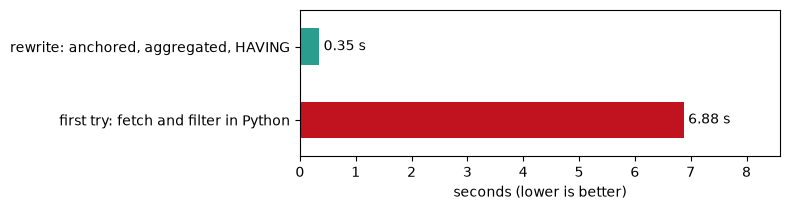

In [11]:
ax = results.seconds.plot.barh(figsize=(8, 2.2), color=['#c1121f', '#2a9d8f'])
ax.set_xlabel('seconds (lower is better)')
ax.bar_label(ax.containers[0], fmt='%.2f s', padding=3)
ax.set_xlim(0, results.seconds.max() * 1.25)
plt.tight_layout(); plt.show()

The profile of the rewrite shows why: the anchor (`ML201 edu:covers ?topic`, 5 rows) and the constant course IRI keep every join small from the start:

In [12]:
print(perf.plan(conn, REWRITE, GRAPHS, profile=True))

Profiling results:
Query executed in 181 ms and returned 853 result(s)
Total used memory: 4.8M
Pre-execution time: 5 ms (2.8%)
Post-processing time: 0 ms (0.0%)
Query plan execution: 176 ms (97.2%)
From <urn:tutorial:ch15:curriculum>
From <urn:tutorial:ch15:sis>
OrderBy(ASC(?avg)) [#204], memory: {total=288K (5.9%)}, results: 853, wall time: 3 ms (1.7%)
`─ Projection(?s, ?avg) [#204], results: 853, wall time: 0 ms (0.0%)
   `─ Bind(ROUND(?_anon_6) AS ?avg) [#204], results: 853, wall time: 1 ms (0.6%)
      `─ Filter("45"^^<http://www.w3.org/2001/XMLSchema#integer> > ?_anon_7) [#204], results: 853, wall time: 4 ms (2.3%)
         `─ Bind(?_anon_6 AS ?_anon_7) [#2.0K], results: 7.5K, wall time: 5 ms (2.8%)
            `─ Group(by=[?s] aggregates=[(AVG(?score) AS ?_anon_6)]) [#2.0K], memory: {total=897K (18.3%); max=769K}, results: 7.5K, wall time: 15 ms (8.5%)
               `─ Restriction(?s, ?score) [#17K], results: 30K (next: 80, avg batch: 374), wall time: 0 ms (0.0%)
               

**The method, in order**

1. **Measure** with repeats and a warm-up (`bench`), not a single run.
2. **Read the plan**: `NestedLoopJoin`, huge estimates, full scans behind `Filter`.
3. **Profile**: which operator takes the time? Do estimates match actual rows?
4. **Rewrite**: anchor, put constants in patterns, aggregate and filter on the server, return only what's needed.
5. **Measure again**, and check the answer is identical.

## 15.6 Safety nets

### Timeouts

Every database has a **`query.timeout`** (default here: 5 minutes). It's the safety net that stops a runaway query from hogging the server. To see it act, lower it temporarily to 10 seconds and run the cartesian product from 15.4:

In [13]:
ORIGINAL_TIMEOUT = dboptions.set_options({'query.timeout': '10s'})
print('query.timeout was', ORIGINAL_TIMEOUT['query.timeout'], '→ now', dboptions.get_options('query.timeout')['query.timeout'])
try:
    start = time.perf_counter()
    try:
        conn.select(CARTESIAN, default_graph_uri=GRAPHS)
        print('finished (unexpected)')
    except stardog.exceptions.StardogException as e:
        print(f'stopped after {time.perf_counter() - start:.0f} s: HTTP {e.http_code}: {str(e).split(": ", 1)[-1][:120]}')
finally:
    dboptions.set_options(ORIGINAL_TIMEOUT)
    print('restored:', dboptions.get_options('query.timeout')['query.timeout'])

query.timeout was 5m → now 10s


stopped after 13 s: HTTP 410: com.complexible.stardog.plan.eval.operator.OperatorException: Query execution cancelled: Execution time exceeded query t


restored: 5m


`query.timeout` can be changed online, and Stardog cancels the query with HTTP **410**.

> ⚠️ The SPARQL protocol also has a per-request `timeout` parameter (pystardog: `conn.select(..., timeout=ms)`). In our tests on this Stardog Cloud server it was **accepted but not applied**: the query kept the database's 5-minute limit. Rely on `query.timeout`, check what your server does, and set a **client-side** timeout too so your application never waits forever.

### Finding and killing a runaway query

When the database feels slow, look at what's running and stop what shouldn't be:

```python
with client.admin() as admin:
    for q in admin.queries():                  # id, user, query text, start time, timeout, status
        print(q['id'], q['user'], q['query'][:60])
    admin.kill_query('<id>')
```

In [14]:
with client.admin() as admin:
    running = admin.queries()
print('running right now:', running or 'nothing')

running right now: nothing


> 🔁 **Neo4j equivalent:** `EXPLAIN` / `PROFILE` show and measure plans (with "db hits"); `db.transaction.timeout` is the global timeout; `SHOW TRANSACTIONS` / `TERMINATE TRANSACTION` find and kill runaway queries. The same anti-patterns apply, and the cartesian product is Cypher's classic too (`MATCH (a), (b)`).

## 15.7 Exercises

**Exercise 1.** Run `plan()` for Chapter 10's `prerequisite_gaps` query (threshold 50, all students) on the scale graphs, then `profile=True`. Which operator takes the most time?

<details><summary>Solution</summary>

```python
q = sparql.load_query('edugraph/prerequisite_gaps').replace('?threshold', '50')
print(perf.plan(conn, q, GRAPHS, profile=True))
```
(`replace` puts the value into the text because `plan()` sends no bindings. It's fine for a fixed number you typed yourself, never for user input.)
</details>

**Exercise 2.** Write the "at-risk" query for **every** course at once (course, student, average), with `HAVING (AVG(?score) < 45)`. Benchmark it.

<details><summary>Solution</summary>

```python
q = P + '''SELECT ?course ?s (ROUND(AVG(?score)) AS ?avg) WHERE {
  ?c edu:covers ?topic ; edu:code ?course . ?s edu:enrolledIn ?c .
  ?a edu:student ?s ; edu:topic ?topic ; edu:score ?score }
GROUP BY ?course ?s HAVING (AVG(?score) < 45)'''
perf.bench(conn, q, GRAPHS)
```
</details>

**Exercise 3.** A colleague's query `SELECT ?s ?n { ?s edu:name ?n . ?x edu:score ?sc }` "hangs". Without running it, how do you prove what's wrong?

<details><summary>Solution</summary>

`perf.plan(conn, P + '…', GRAPHS)` shows a `NestedLoopJoin` with an estimate in the billions: `?s`/`?n` and `?x`/`?sc` share no variable. The second pattern was probably meant to be `?x edu:student ?s ; edu:score ?sc`.
</details>

**Exercise 4.** Measure keyset paging for **page 1,000** of students ordered by IRI (100 per page). How do you get the key for the next page?

<details><summary>Solution</summary>

The key is the **last IRI of the current page**: send it back with the next request and continue with `FILTER(STR(?s) > "<last key>") ORDER BY ?s LIMIT 100`. To jump straight to page 1,000 you need the key at position 99,900, which is why keyset paging suits "next page" navigation rather than random access.
</details>

In [15]:
# your answers here

## 15.8 Clean up

In [16]:
CLEAN_UP = True

if CLEAN_UP:
    with client.transaction(conn):
        for g in GRAPHS:
            conn.clear(graph_uri=g)
    print('removed', GRAPHS, '| query.timeout:', dboptions.get_options('query.timeout')['query.timeout'])
conn.close()

removed ['urn:tutorial:ch15:sis', 'urn:tutorial:ch15:curriculum'] | query.timeout: 5m


## Summary

- Time = network + planning + execution + serialization + transfer. On a remote server, **round trips** dominate small queries: send fewer, larger requests and move **questions, not data**.
- **Plans** (`perf.plan`) show operators, indexes and **estimates**. `NestedLoopJoin` with huge estimates means disconnected patterns; a `Filter` over a full scan means a hidden index lookup.
- **Profiles** (`profile=True`) measure each operator and reveal wrong estimates.
- Rewrites that matter: **aggregate on the server**, **constants in patterns**, **connect every pattern**, **anchor joins and paths**, **keyset paging**, **return only what you use**.
- **Benchmark** with warm-ups and medians, and verify the answer didn't change.
- Safety nets: **`query.timeout`** (verified), a client-side timeout, and `admin.queries()` / `kill_query()`.

**Next: Chapter 15b, Graph analytics.** PageRank, components, communities and triangles on the supply chain network, with the Stardog Spark connector.